In [26]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
path = '/kaggle/input'
# listdir() returns everything; check isdir() to filter
dir_name = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]

for d in dir_name:
    print(d) 
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

datasets


In [27]:
# import libraries

import os
import numpy as np
import pandas as pd
import cv2

In [28]:
# load tabluar data
CSV_PATH = "/kaggle/input/datasets/ted8080/house-prices-and-images-socal/socal2.csv"

df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
display(df.head())
print(df.columns.tolist())

Shape: (15474, 8)


,image_id,street,citi,n_citi,bed,bath,sqft,price
0,0,1317 Van Buren Avenue,"Salton City, CA",317,3,2.0,1560,201900
1,1,124 C Street W,"Brawley, CA",48,3,2.0,713,228500
2,2,2304 Clark Road,"Imperial, CA",152,3,1.0,800,273950
3,3,755 Brawley Avenue,"Brawley, CA",48,3,1.0,1082,350000
4,4,2207 R Carrillo Court,"Calexico, CA",55,4,3.0,2547,385100


['image_id', 'street', 'citi', 'n_citi', 'bed', 'bath', 'sqft', 'price']


In [29]:
# Keeping only the street name, not the house number
df["street_name"] = (
    df["street"].astype(str)
      .str.replace(r"^\d+\s+", "", regex=True)
      .str.strip()
      .fillna("unknown")
)

df["citi"] = df["citi"].astype(str).fillna("unknown")


In [30]:
# Load Image path
IMG_DIR = "/kaggle/input/datasets/ted8080/house-prices-and-images-socal/socal2/socal_pics"

# Build a lookup from image filename (without extension) to full path
image_lookup = {}
for fname in os.listdir(IMG_DIR):
    base, ext = os.path.splitext(fname)
    if ext.lower() in [".jpg", ".jpeg", ".png"]:
        image_lookup[base] = os.path.join(IMG_DIR, fname)


# Find the image file for a given image_id
def resolve_image_path(image_id):
    key = str(image_id)
    if key in image_lookup:
        return image_lookup[key]

    # fallback in case files are named like 0.jpg, 1.png, etc.
    for ext in [".jpg", ".jpeg", ".png"]:
        candidate = os.path.join(IMG_DIR, f"{key}{ext}")
        if os.path.exists(candidate):
            return candidate

    raise FileNotFoundError(f"No image found for image_id={image_id}")

df["image_path"] = df["image_id"].apply(resolve_image_path)

print(df[["image_id", "image_path", "price"]].head())

   image_id                                         image_path   price
0         0  /kaggle/input/datasets/ted8080/house-prices-an...  201900
1         1  /kaggle/input/datasets/ted8080/house-prices-an...  228500
2         2  /kaggle/input/datasets/ted8080/house-prices-an...  273950
3         3  /kaggle/input/datasets/ted8080/house-prices-an...  350000
4         4  /kaggle/input/datasets/ted8080/house-prices-an...  385100


In [31]:
import random

# Reproducibility helps you compare experiments fairly
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [32]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# Split the data before fitting encoders/scalers
df['price_bin'] = pd.qcut(df['price'], q=10, duplicates='drop')

# Price-binned stratification keeps price distribution similar across splits
train_df, temp_df = train_test_split(df,      test_size=0.30, random_state=SEED, stratify=df['price_bin'])
val_df,   test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['price_bin'])

# Drop the helper bin column from the final dataframes
for frame in [train_df, val_df, test_df]:
    frame.drop(columns=["price_bin"], inplace=True)

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)
#print(f'Train: {train_df.shape} | Val: {val_df.shape} | Test: {test_df.shape}')

Train: (10831, 10)
Val:   (2321, 10)
Test:  (2322, 10)


In [33]:
# Tabular preprocessing

from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np

# Frequency-encode street name (fit only on train to avoid data leakage)
street_freq = train_df['street_name'].value_counts().to_dict()
for frame in [train_df, val_df, test_df]:
    frame['street_freq'] = frame['street_name'].map(street_freq).fillna(0).astype(float)

# Numeric features for the tabular branch
num_cols = ["street_freq", "bed", "bath", "sqft"]
cat_cols = ["citi"]

# Scale numeric columns (fit only on train)
scaler = StandardScaler()
X_num_train = scaler.fit_transform(train_df[num_cols])
X_num_val   = scaler.transform(val_df[num_cols])
X_num_test  = scaler.transform(test_df[num_cols])

# One-hot encode city (fit only on train)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat_train = ohe.fit_transform(train_df[cat_cols])
X_cat_val   = ohe.transform(val_df[cat_cols])
X_cat_test  = ohe.transform(test_df[cat_cols])

# Combine numeric + categorical features
X_tab_train = np.hstack([X_num_train, X_cat_train]).astype(np.float32)
X_tab_val   = np.hstack([X_num_val,   X_cat_val  ]).astype(np.float32)
X_tab_test  = np.hstack([X_num_test,  X_cat_test ]).astype(np.float32)

# Use Log-transform on price, to shrink the range, helps the model learn more evenly
# We use log1p (= log(1+x)) so that price=0 doesn't cause -inf
y_train = np.log1p(train_df['price'].values).astype(np.float32)
y_val   = np.log1p(val_df['price'].values).astype(np.float32)
y_test  = np.log1p(test_df['price'].values).astype(np.float32)

print('Tabular train shape:', X_tab_train.shape)
print('City categories:', len(ohe.categories_[0]))

Tabular train shape: (10831, 409)
City categories: 405


In [34]:
# Image preprocessing

import torch
from torchvision import models, transforms

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# train with augmentaion
train_img_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

eval_img_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])


In [35]:
# Custom Dataset and DataLoaders
from torch.utils.data import Dataset, DataLoader

class HouseDataset(Dataset):
    def __init__(self, frame, tabular_array, targets, transform=None):
        self.frame   = frame.reset_index(drop=True).copy()
        self.tab     = torch.tensor(tabular_array, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)
        self.transform = transform

    def __len__(self): return len(self.frame)

    def __getitem__(self, idx):
        # Load image
        img = Image.open(self.frame.iloc[idx]['image_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.tab[idx], self.targets[idx]


train_ds = HouseDataset(train_df, X_tab_train, y_train, train_img_tf)
val_ds   = HouseDataset(val_df,   X_tab_val,   y_val,   eval_img_tf)
test_ds  = HouseDataset(test_df,  X_tab_test,  y_test,  eval_img_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
print('Loaders ready')

Loaders ready


In [36]:
# Multimodal model: ResNet18 + tabular MLP + fusion head

import torch.nn as nn
from torchvision.models import ResNet18_Weights

#  MLP, which outputs a 64-dim feature vector
class TabularBranch(nn.Module):
    def __init__(self, input_dim, out_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, out_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)


# class TabularBranch(nn.Module):
#     def __init__(self, input_dim, out_dim=64):
#         super().__init__()
#         backbone = models.resnet18(weights=ResNet18_Weights.DEFAULT)

#         # Remove classification head completely
#         self.feature_extractor = nn.Sequential(
#             *list(backbone.children())[:-1]
#         )

#     def forward(self, x):

#         x = self.feature_extractor(x)

#         # Flatten from (B, 512, 1, 1) -> (B, 512)
#         x = torch.flatten(x, 1)

#         return x

# ResNet18 pretrained on ImageNet, which outputs a 512-dim feature vector
class ImageBranch(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        backbone.fc = nn.Identity()
        self.backbone = backbone

    def forward(self, x):
        return self.backbone(x.float())


# class ImageBranch(nn.Module):
#     def __init__(self):
#         super().__init__()
#         # Use pretrained weights 
#         backbone = models.resnet18(weights=ResNet18_Weights.DEFAULT)
#         backbone.fc = nn.Identity()   # remove the classifier, keep 512-dim features
#         self.backbone = backbone
#     def forward(self, x):
#         return self.backbone(x.float())


# combines both feature vectors and outputs a single price prediction
class MultiModalRegressor(nn.Module):
    def __init__(self, tab_input_dim):
        super().__init__()
        self.image_branch = ImageBranch()
        self.tab_branch = TabularBranch(tab_input_dim, out_dim=64)
        self.fusion = nn.Sequential(
            nn.Linear(512 + 64, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, img, tab):
        img_feat = self.image_branch(img)
        tab_feat = self.tab_branch(tab)
        features = torch.cat([img_feat, tab_feat], dim=1)
        return self.fusion(features).squeeze(1)

model = MultiModalRegressor(tab_input_dim=X_tab_train.shape[1]).to(device)
total = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total:,}')

Total parameters: 11,319,681


In [37]:
imgs, tabs, targets = next(iter(train_loader))

print("imgs shape:", imgs.shape)
print("imgs dtype:", imgs.dtype)
print("tabs shape:", tabs.shape)
print("targets shape:", targets.shape)

imgs shape: torch.Size([32, 3, 224, 224])
imgs dtype: torch.float32
tabs shape: torch.Size([32, 409])
targets shape: torch.Size([32])


In [38]:
# Training: Only the tabular branch and fusion head train
criterion = nn.SmoothL1Loss()

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    for imgs, tabs, targets in loader:
        imgs, tabs, targets = imgs.to(device), tabs.to(device), targets.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs, tabs), targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    for imgs, tabs, targets in loader:
        imgs, tabs, targets = imgs.to(device), tabs.to(device), targets.to(device)
        total_loss += criterion(model(imgs, tabs), targets).item() * imgs.size(0)
    return total_loss / len(loader.dataset)


# Stage1: freeze CNN backbone 
for p in model.image_branch.backbone.parameters():
    p.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Stage 1 trainable params: {trainable:,}')

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

history = {'train': [], 'val': []}

STAGE1_EPOCHS = 12
for epoch in range(STAGE1_EPOCHS):
    tr = train_one_epoch(model, train_loader, optimizer)
    vl = evaluate(model, val_loader)
    scheduler.step(vl)
    history['train'].append(tr)
    history['val'].append(vl)
    print(f'[Stage1] Epoch {epoch+1:02d}/{STAGE1_EPOCHS} | train={tr:.5f} | val={vl:.5f}')

Stage 1 trainable params: 143,169
[Stage1] Epoch 01/12 | train=1.63460 | val=0.54035
[Stage1] Epoch 02/12 | train=1.10176 | val=0.37645
[Stage1] Epoch 03/12 | train=1.04340 | val=0.34318
[Stage1] Epoch 04/12 | train=0.99320 | val=0.31937
[Stage1] Epoch 05/12 | train=0.97827 | val=0.28272
[Stage1] Epoch 06/12 | train=0.92330 | val=0.44623
[Stage1] Epoch 07/12 | train=0.87727 | val=0.25166
[Stage1] Epoch 08/12 | train=0.84169 | val=0.39820
[Stage1] Epoch 09/12 | train=0.78070 | val=0.24271
[Stage1] Epoch 10/12 | train=0.74535 | val=0.17004
[Stage1] Epoch 11/12 | train=0.68296 | val=0.14763
[Stage1] Epoch 12/12 | train=0.62209 | val=0.11983


In [39]:
# Stage 2: unfreeze layer4, fine-tune with low LR
for p in model.image_branch.backbone.layer4.parameters():
    p.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Stage 2 trainable params: {trainable:,}')

optimizer = torch.optim.AdamW([
    {'params': model.tab_branch.parameters(),                   'lr': 1e-4},
    {'params': model.fusion.parameters(),                       'lr': 1e-4},
    {'params': model.image_branch.backbone.layer4.parameters(), 'lr': 1e-5},
], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

STAGE2_EPOCHS = 10
for epoch in range(STAGE2_EPOCHS):
    tr = train_one_epoch(model, train_loader, optimizer)
    vl = evaluate(model, val_loader)
    scheduler.step(vl)
    history['train'].append(tr)
    history['val'].append(vl)
    print(f'[Stage2] Epoch {epoch+1:02d}/{STAGE2_EPOCHS} | train={tr:.5f} | val={vl:.5f}')

Stage 2 trainable params: 8,536,897
[Stage2] Epoch 01/10 | train=0.52747 | val=0.09388
[Stage2] Epoch 02/10 | train=0.49662 | val=0.07104
[Stage2] Epoch 03/10 | train=0.48182 | val=0.06893
[Stage2] Epoch 04/10 | train=0.47108 | val=0.11287
[Stage2] Epoch 05/10 | train=0.48433 | val=0.06312
[Stage2] Epoch 06/10 | train=0.46882 | val=0.06198
[Stage2] Epoch 07/10 | train=0.46544 | val=0.05770
[Stage2] Epoch 08/10 | train=0.46226 | val=0.05540
[Stage2] Epoch 09/10 | train=0.43772 | val=0.05431
[Stage2] Epoch 10/10 | train=0.43640 | val=0.04901


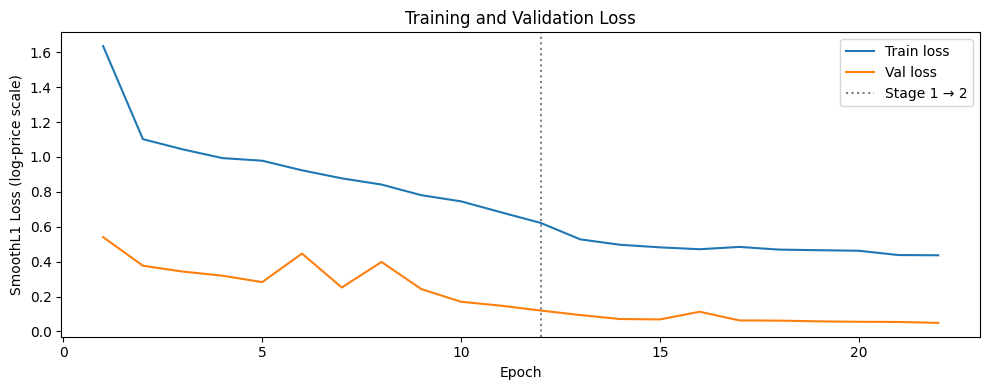

In [40]:
plt.figure(figsize=(10, 4))
epochs = range(1, len(history['train']) + 1)
plt.plot(epochs, history['train'], label='Train loss')
plt.plot(epochs, history['val'],   label='Val loss')
plt.axvline(STAGE1_EPOCHS, color='gray', linestyle=':', label='Stage 1 → 2')
plt.xlabel('Epoch')
plt.ylabel('SmoothL1 Loss (log-price scale)')
plt.title('Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
@torch.no_grad()
def get_predictions(model, loader):
    """Returns (y_true, y_pred) both in log-price space."""
    model.eval()
    preds, trues = [], []
    for imgs, tabs, targets in loader:
        imgs, tabs = imgs.to(device), tabs.to(device)
        preds.append(model(imgs, tabs).cpu().numpy())
        trues.append(targets.numpy())
    return np.concatenate(trues), np.concatenate(preds)


# Get predictions in log-space, then convert back to real dollar amounts
y_log_true, y_log_pred = get_predictions(model, test_loader)

# expm1 is the exact inverse of log1p
y_true = np.expm1(y_log_true)
y_pred = np.expm1(y_log_pred)

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f'Test MAE : ${mae:>12,.0f}')
print(f'Test RMSE: ${rmse:>12,.0f}')

Test MAE : $     167,162
Test RMSE: $     265,350


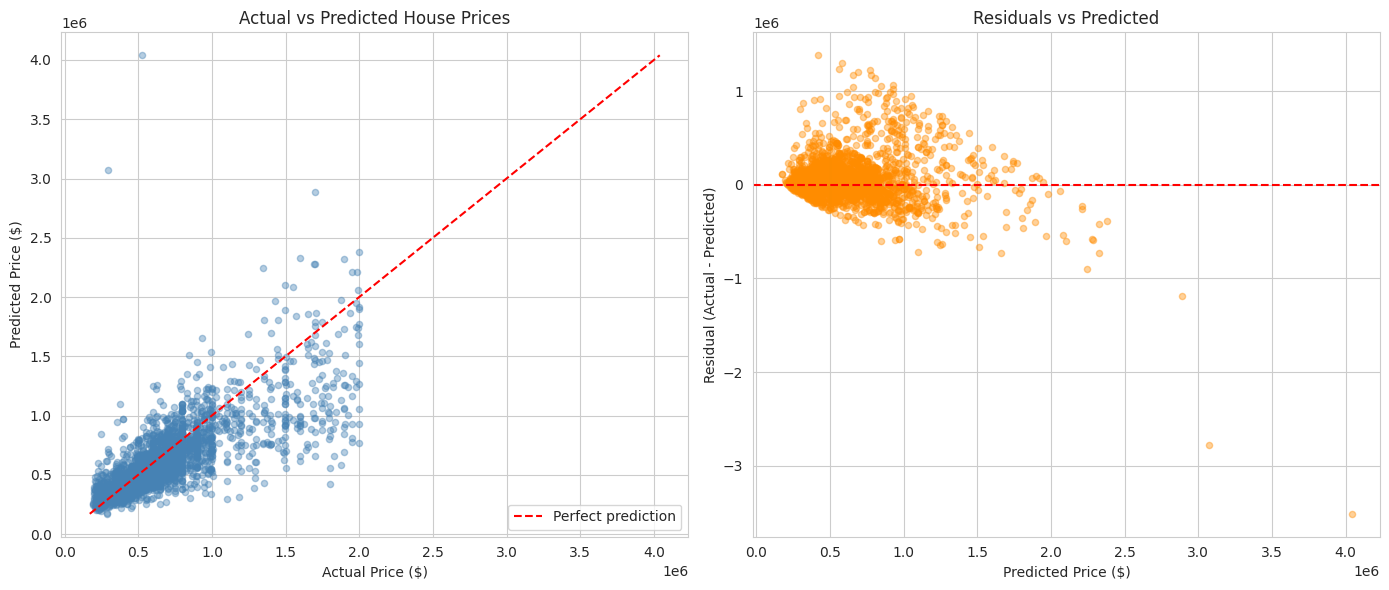

In [42]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter Plot: Actual vs Predicted
ax = axes[0]
ax.scatter(y_true, y_pred, alpha=0.4, s=20, color='steelblue')
lo = min(y_true.min(), y_pred.min())
hi = max(y_true.max(), y_pred.max())
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Price ($)')
ax.set_ylabel('Predicted Price ($)')
ax.set_title('Actual vs Predicted House Prices')
ax.legend()

# Plotting residuals: Residuals = Actual - Predicted
residuals = y_true - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, s=20, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()